In [24]:
import numpy as np
import matplotlib.pyplot as plt
import subprocess
import os

In [60]:
BIN = "./main"
PARAM_FILE = "temp_yield.par"
MDM_VAL = 100

In [49]:
def run_micromegas(gamma, vchi):
    with open(PARAM_FILE, "w") as f:
        f.write(f"Mdm {MDM_VAL}\n")   
        f.write(f"MZp 1.0\n")         
        f.write(f"gZp 1e-5\n")        
        f.write(f"gZpDm {vchi}\n")    
        f.write(f"Gamma {gamma}\n")   
        f.write(f"H0 0.1\n")          
        

    res = subprocess.run([BIN, PARAM_FILE], capture_output=True, text=True)
    
    if res.returncode != 0:
        print(f"Error ejecutando micrOMEGAs:\n{res.stdout}\n{res.stderr}")
        raise RuntimeError("micrOMEGAs falló al ejecutarse.")

    with open("output_data.txt", "r") as f:
        line1 = f.readline()
        meta = {x.split('=')[0]: float(x.split('=')[1]) for x in line1.replace("#", "").strip().split()}
        
    data = np.genfromtxt("output_data.txt", skip_header=1, names=True)
        
    return data, meta

In [56]:
scenarios = [
    {"label": "WIMP", "vchi": 1.1e-1, "gamma": 1e-17, "color": "black",},
    {"label": "FIMP", "vchi": 5.7e-4, "gamma": 1e-17, "color": "blue",},
    {"label": "WIMP (G=1e-18)", "vchi": 1.1e-1, "gamma": 1e-18, "color": "green", "ls": ":"},
    {"label": "FIMP (G=1e-18)", "vchi": 5.7e-4, "gamma": 1e-18, "color": "red", "ls": ":"}
]

/tmp/ipykernel_1650359/2911145275.py:7: RuntimeWarning: divide by zero encountered in divide
  x = MDM_VAL / data['Ta']


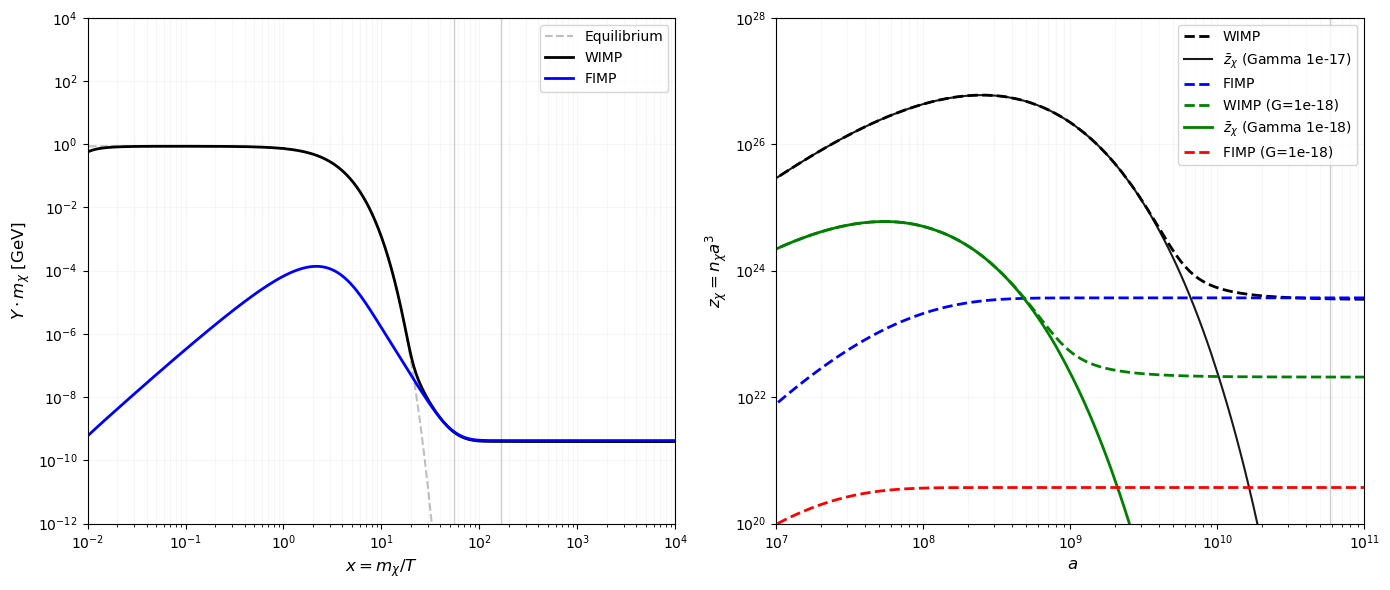

In [61]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for sc in scenarios:
    data, meta = run_micromegas(sc['gamma'], sc['vchi'])
    
    # Yield vs x 
    x = MDM_VAL / data['Ta']
    y_scaled = data['Ya'] * MDM_VAL
    yeq_scaled = data['YaEq'] * MDM_VAL
    ZaE_scaled = data['ZaEq'] * MDM_VAL
    mask = x >= (MDM_VAL / meta['Tmax'])
    if sc['label'] == "WIMP":
        ax1.plot(x[mask], yeq_scaled[mask], '--', color='gray', alpha=0.5, label='Equilibrium')

    if "1e-18" not in sc['label']:
        ax1.plot(x[mask], y_scaled[mask], label=sc['label'], color=sc['color'], lw=2)

    # Z vs a 
    ax2.plot(data['a'], data['Za'], color=sc['color'], ls ='--', lw=2, label=sc['label'])
    
    if sc['label'] == "WIMP":
        ax2.plot(data['a'], data['ZaEq'], color='black', alpha=0.9, label=rf'$\bar{{z}}_\chi$ (Gamma 1e-17)')
    
    elif sc['label'] == "WIMP (G=1e-18)":
        ax2.plot(data['a'], data['ZaEq'], color='green', lw=2, label=rf'$\bar{{z}}_\chi$ (Gamma 1e-18)')
        

        

    arh = MDM_VAL / (MDM_VAL / data['a'][np.argmin(np.abs(data['Ta'] - meta['Trh']))])
    ax1.axvline(MDM_VAL/meta['Trh'], color='k', alpha=0.1, lw=1)
    ax2.axvline(arh, color='k', alpha=0.1, lw=1)





ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlim(1e-2, 1e4)
ax1.set_ylim(1e-12, 1e4)
ax1.set_xlabel(r'$x = m_\chi / T$', fontsize=12)
ax1.set_ylabel(r'$Y \cdot m_\chi$ [GeV]', fontsize=12)
ax1.legend()
ax1.grid(True, which="both", ls="-", alpha=0.1)

ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlim(1e7, 1e11)
ax2.set_ylim(1e20, 1e28)
ax2.set_xlabel(r' $a$', fontsize=12)
ax2.set_ylabel(r'$z_\chi = n_\chi a^3$', fontsize=12)
ax2.legend()
ax2.grid(True, which="both", ls="-", alpha=0.1)

plt.tight_layout()
plt.show()